# Explore a Dipole: Cancellation and Distance

The same two charges can look like separate point sources nearby and a dipole from far away. This notebook lets you see **what is added, what cancels, and what remains**. It accompanies {doc}`from_currents_to_dipoles`.

The controls below work directly in the built book, without starting a Python kernel. In Jupyter, run all cells in a trusted notebook to recreate the controls and the calculation beneath them. A {download}`standalone version <dipole_lab.html>` is also available. The Python cells are self-contained; the interactive display uses the same analytical formulas in JavaScript.

## The model and its units

Put $+Q$ at $(0,0,d/2)$ and $-Q$ at $(0,0,-d/2)$. The displayed plane is $y=0$, a cross-section of a **three-dimensional** field. Choose a fixed length unit $L_0$ and charge unit $Q_0$; coordinates below are in $L_0$, charge in $Q_0$, potential in $k_eQ_0/L_0$, and field in $k_eQ_0/L_0^2$. The dimensionless Coulomb constant is then one. Changing the viewing half-width $L$ changes the window, not the units.

For a source at $\vec r_i$, use

$$
V_i=\frac{Q_i}{|\vec r-\vec r_i|},\qquad
\vec E_i=Q_i\frac{\vec r-\vec r_i}{|\vec r-\vec r_i|^3}.
$$

Add the two potentials as scalars and the fields as vectors. The midpoint is the origin and $\vec p=Qd\hat z$.

**Before touching the sliders:** predict the potential and field direction at the midpoint. Does zero potential imply zero field?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display

def contribution(x, z, source_z, charge):
    """Exact point-charge potential, Ex, Ez; singular at the source."""
    x, z = np.broadcast_arrays(np.asarray(x, float), np.asarray(z, float))
    dz = z - source_z
    r = np.hypot(x, dz)
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.array([charge / r, charge*x/r**3, charge*dz/r**3])

def charge_pair(x, z, d=1.0, Q=1.0):
    plus = contribution(x, z, d/2, Q)
    minus = contribution(x, z, -d/2, -Q)
    return plus, minus, plus + minus

def ideal_dipole(x, z, p=1.0):
    x, z = np.broadcast_arrays(np.asarray(x, float), np.asarray(z, float))
    r = np.hypot(x, z)
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.array([p*z/r**3, 3*p*z*x/r**5,
                         p*(3*z*z/r**5 - 1/r**3)])

# Check symmetry and the gradient relation before using the formulas.
np.testing.assert_allclose(charge_pair(0, 0)[2], [0, 0, -8])
np.testing.assert_allclose(charge_pair(2, 0)[2][0], 0)
x, z, eps = 1.5, 1.5, 1e-5
exact = charge_pair(x, z)[2]
gx = -(charge_pair(x+eps,z)[2][0]-charge_pair(x-eps,z)[2][0])/(2*eps)
gz = -(charge_pair(x,z+eps)[2][0]-charge_pair(x,z-eps)[2][0])/(2*eps)
np.testing.assert_allclose(exact[1:], [gx,gz], rtol=1e-8)
# At a distant point the ideal dipole converges to the finite pair.
far = charge_pair(30, 40)[2]
np.testing.assert_allclose(far, ideal_dipole(30,40), rtol=5e-4)
print("Symmetry, gradient and far-field checks passed.")


Symmetry, gradient and far-field checks passed.


In [2]:
# The HTML contains all controls and drawing code, with no external dependencies.
# An iframe keeps the explorer independent of the notebook/page styles.
import html as html_module
explorer_html = '<!doctype html><html lang="en"><head><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1">\n<style>\n*{box-sizing:border-box}body{margin:0;padding:12px;font:14px system-ui,sans-serif;color:#203541;background:#fff}h2{font-size:21px;margin:0 0 8px}p{line-height:1.45;margin:8px 0}.controls{display:grid;grid-template-columns:1fr 1fr;gap:10px 24px;margin:15px 0}label{display:block;font-weight:600}input[type=range]{width:100%;accent-color:#007da5}select,button{font:inherit;padding:6px;background:white;border:1px solid #8a9da7;border-radius:4px}output{font-variant-numeric:tabular-nums;font-weight:400}.scroll{overflow-x:auto}.panels{display:grid;grid-template-columns:repeat(3,1fr);min-width:0;gap:6px}.panel{margin:0}.panel figcaption{text-align:center;font-weight:600;font-size:13px;margin:6px 0}canvas{display:block;width:100%;height:auto;border:1px solid #d6dfe4;touch-action:manipulation}.legend{font-size:12px;color:#415764}.probe{display:grid;grid-template-columns:1fr 1fr;gap:15px;margin-top:16px}table{border-collapse:collapse;width:100%;font-size:13px}th,td{border-bottom:1px solid #d6dfe4;text-align:right;padding:5px}th:first-child,td:first-child{text-align:left}#vectors{max-width:350px}.status{padding:8px;background:#eef6f8}button{cursor:pointer}button:hover{background:#eef6f8}@media(max-width:580px){.controls,.probe{grid-template-columns:1fr}body{font-size:13px}}@media(prefers-reduced-motion:reduce){*{scroll-behavior:auto}}\n</style></head><body>\n<h2>Two charges: contributions and cancellation</h2>\n<p>Positive charge at <b>z = +d/2</b>, negative charge at <b>z = −d/2</b>. Coordinates and values use the dimensionless units defined in the notebook. Start with fixed charge and move farther away by increasing the viewing half-width L.</p>\n<div class="controls">\n<div><label for="d">Separation d: <output id="dv"></output></label><input id="d" type="range" min="0.2" max="2" step="0.1" value="1"></div>\n<div><label for="L">Viewing half-width L: <output id="Lv"></output></label><input id="L" type="range" min="1.5" max="12" step="0.5" value="3"></div>\n<div><label for="mode">What stays fixed?</label><select id="mode"><option value="charge">Charge magnitude Q = 1</option><option value="moment">Dipole moment p = Qd = 1</option></select></div>\n<div><label for="gain">Field-arrow gain: <output id="gainv"></output></label><input id="gain" type="range" min="-1" max="2" step="0.1" value="0"></div>\n<div><label for="px">Probe horizontal position x/L: <output id="pxv"></output></label><input id="px" type="range" min="-0.9" max="0.9" step="0.025" value="0.5"></div>\n<div><label for="pz">Probe vertical position z/L: <output id="pzv"></output></label><input id="pz" type="range" min="-0.9" max="0.9" step="0.025" value="0.5"></div>\n</div>\n<button id="reset" type="button">Reset</button> <label style="display:inline;font-weight:400"><input id="approx" type="checkbox"> Show ideal dipole at the probe</label>\n<p class="legend">Click any panel to move the probe. Top: signed potential, blue negative and red positive; white is zero. All three panels use the same fixed colour scale, with a nonlinear asinh stretch; colours saturate at |V| = 4. Bottom: arrow lengths are linear in field magnitude with the same gain in every panel; arrows longer than 22 pixels are capped and marked by a dot. Small disks of radius 0.08 around the source locations are masked.</p>\n<div class="scroll"><div class="panels">\n<figure class="panel"><figcaption>Potential from +Q</figcaption><canvas id="v0" width="300" height="300" aria-label="Potential of positive charge"></canvas></figure>\n<figure class="panel"><figcaption>Potential from −Q</figcaption><canvas id="v1" width="300" height="300" aria-label="Potential of negative charge"></canvas></figure>\n<figure class="panel"><figcaption>Potential: sum</figcaption><canvas id="v2" width="300" height="300" aria-label="Sum of the two potentials"></canvas></figure>\n<figure class="panel"><figcaption>Field from +Q</figcaption><canvas id="e0" width="300" height="300" aria-label="Electric field of positive charge"></canvas></figure>\n<figure class="panel"><figcaption>Field from −Q</figcaption><canvas id="e1" width="300" height="300" aria-label="Electric field of negative charge"></canvas></figure>\n<figure class="panel"><figcaption>Field: vector sum</figcaption><canvas id="e2" width="300" height="300" aria-label="Vector sum of electric fields"></canvas></figure>\n</div></div>\n<p class="status" id="status" aria-live="polite"></p>\n<div class="probe"><div><h3>At the probe</h3><table><thead><tr><th>Contribution</th><th>V</th><th>Eₓ</th><th>E𝓏</th></tr></thead><tbody id="values"></tbody></table><p class="legend" id="error"></p></div><div><h3>Add the vectors head to tail</h3><canvas id="vectors" width="350" height="240" aria-label="Head-to-tail vector addition at the probe"></canvas><p class="legend">Orange: E₊. Blue: E₋, starting at E₊\'s tip. Black: the sum. Probe arrows share one scale, automatically fitted to this diagram. Dashed green: ideal dipole, if selected.</p></div></div>\n<p><b>Predict:</b> keep Q fixed and halve d. What happens to the distant field? Then reset, keep d fixed and increase L. Compare r/d and the dipole error at the probe. Finally keep p fixed: are you still changing only the separation?</p>\n<script>\n(()=>{\'use strict\';const $=id=>document.getElementById(id);const ids=[\'d\',\'L\',\'mode\',\'gain\',\'px\',\'pz\',\'approx\'];\nfunction contribution(x,z,zq,q){const dz=z-zq,r=Math.hypot(x,dz);return [q/r,q*x/r**3,q*dz/r**3]}\nfunction pair(x,z,d,q){const a=contribution(x,z,d/2,q),b=contribution(x,z,-d/2,-q);return [a,b,a.map((v,i)=>v+b[i])]}\nfunction dipole(x,z,p){const r=Math.hypot(x,z);return [p*z/r**3,3*p*z*x/r**5,p*(3*z*z/r**5-1/r**3)]}\nfunction arrow(c,x,y,dx,dy,color,dashed=false){const n=Math.hypot(dx,dy);if(n<.15)return;c.strokeStyle=color;c.fillStyle=color;c.lineWidth=1.4;c.setLineDash(dashed?[5,3]:[]);c.beginPath();c.moveTo(x,y);c.lineTo(x+dx,y+dy);c.stroke();c.setLineDash([]);const a=Math.atan2(dy,dx),h=Math.min(6,n*.4);c.beginPath();c.moveTo(x+dx,y+dy);c.lineTo(x+dx-h*Math.cos(a-.45),y+dy-h*Math.sin(a-.45));c.lineTo(x+dx-h*Math.cos(a+.45),y+dy-h*Math.sin(a+.45));c.closePath();c.fill()}\nfunction color(v){let t=Math.min(1,Math.asinh(Math.abs(v)/.2)/Math.asinh(4/.2));const end=v<0?[25,87,160]:[185,35,50];return `rgb(${end.map(a=>Math.round(255+(a-255)*t)).join(\',\')})`}\nfunction drawPanel(canvas,index,potential,s){const c=canvas.getContext(\'2d\'),m=25,w=250,h=250;c.clearRect(0,0,300,300);const to=(x,z)=>[m+(x/s.L+1)*w/2,m+(1-z/s.L)*h/2];\n if(potential){const n=60;for(let j=0;j<n;j++)for(let i=0;i<n;i++){let x=(2*(i+.5)/n-1)*s.L,z=(1-2*(j+.5)/n)*s.L;let masked=Math.min(Math.hypot(x,z-s.d/2),Math.hypot(x,z+s.d/2))<.08;c.fillStyle=masked?\'#ddd\':color(pair(x,z,s.d,s.q)[index][0]);c.fillRect(m+i*w/n,m+j*h/n,w/n+.5,h/n+.5)}}\n else{c.fillStyle=\'#fafcfd\';c.fillRect(m,m,w,h);for(let j=0;j<15;j++)for(let i=0;i<15;i++){let x=(2*(i+.5)/15-1)*s.L,z=(1-2*(j+.5)/15)*s.L;if(Math.min(Math.hypot(x,z-s.d/2),Math.hypot(x,z+s.d/2))<.08)continue;let e=pair(x,z,s.d,s.q)[index],dx=e[1]*16*s.gain,dy=-e[2]*16*s.gain,len=Math.hypot(dx,dy),cap=len>22;if(cap){dx*=22/len;dy*=22/len}let [xp,zp]=to(x,z);arrow(c,xp-dx/2,zp-dy/2,dx,dy,\'#1769aa\');if(cap){c.fillStyle=\'#bd561b\';c.beginPath();c.arc(xp,zp,1.6,0,7);c.fill()}}}\n c.strokeStyle=\'#7b8d96\';c.lineWidth=.6;c.strokeRect(m,m,w,h);c.font=\'11px system-ui\';c.fillStyle=\'#203541\';c.textAlign=\'center\';c.fillText(\'x\',150,298);c.fillText((-s.L).toFixed(1),m,289);c.fillText(s.L.toFixed(1),m+w,289);c.fillText(\'z\',10,18);c.textAlign=\'left\';\n for(let sign of [-1,1]){let [x,y]=to(0,sign*s.d/2);c.beginPath();c.arc(x,y,7,0,7);c.fillStyle=\'white\';c.fill();c.strokeStyle=sign>0?\'#bd561b\':\'#1769aa\';c.stroke();c.fillStyle=c.strokeStyle;c.textAlign=\'center\';c.fillText(sign>0?\'+\':\'−\',x,y+4)}\n let [x,y]=to(s.x,s.z);c.strokeStyle=\'#000\';c.lineWidth=1.5;c.beginPath();c.arc(x,y,5,0,7);c.stroke();c.fillStyle=\'#000\';c.fillText(\'P\',x+10,y-6)\n}\nfunction render(){let s={d:+$(\'d\').value,L:+$(\'L\').value,gain:10**+$(\'gain\').value};s.q=$(\'mode\').value===\'charge\'?1:1/s.d;s.x=+$(\'px\').value*s.L;s.z=+$(\'pz\').value*s.L;\nfor(let id of [\'d\',\'L\',\'px\',\'pz\'])$(id+\'v\').textContent=(+$ (id).value).toFixed(2);$(\'gainv\').textContent=s.gain.toFixed(2);\nfor(let i=0;i<3;i++){drawPanel($(\'v\'+i),i,true,s);drawPanel($(\'e\'+i),i,false,s)}\nconst r=Math.hypot(s.x,s.z),near=Math.min(Math.hypot(s.x,s.z-s.d/2),Math.hypot(s.x,s.z+s.d/2))<.08;\n$(\'status\').textContent=`Q = ${s.q.toFixed(3)}, p = Qd = ${(s.q*s.d).toFixed(3)}. Probe (x,z) = (${s.x.toFixed(2)}, ${s.z.toFixed(2)}); r/d = ${(r/s.d).toFixed(2)}.`;\nconst ctx=$(\'vectors\').getContext(\'2d\');ctx.clearRect(0,0,350,240);\nif(near){$(\'values\').innerHTML=\'<tr><td colspan="4">Probe lies in a masked source region. Move it away.</td></tr>\';$(\'error\').textContent=\'Point charges are singular; no softened source is substituted.\';return}\nlet vals=pair(s.x,s.z,s.d,s.q),approx=r>.08?dipole(s.x,s.z,s.q*s.d):null;\nlet names=[\'+Q\',\'−Q\',\'Sum\'];if($(\'approx\').checked&&approx){vals.push(approx);names.push(\'Ideal dipole\')}\n$(\'values\').innerHTML=vals.map((row,i)=>\'<tr><td>\'+names[i]+\'</td>\'+row.map(v=>\'<td>\'+v.toPrecision(3)+\'</td>\').join(\'\')+\'</tr>\').join(\'\');\nlet e=vals[2],mag=Math.hypot(e[1],e[2]);$(\'error\').textContent=$(\'approx\').checked?(approx?`Relative vector-field error of dipole: ${(100*Math.hypot(approx[1]-e[1],approx[2]-e[2])/mag).toFixed(2)}%. Potential may vanish by symmetry even when the field does not.`:\'Ideal dipole is singular at the origin.\'):\'\';\nlet pts=[[0,0],[vals[0][1],vals[0][2]],[e[1],e[2]]];if($(\'approx\').checked&&approx)pts.push([approx[1],approx[2]]);\nlet xs=pts.map(p=>p[0]),zs=pts.map(p=>p[1]),xmin=Math.min(...xs),xmax=Math.max(...xs),zmin=Math.min(...zs),zmax=Math.max(...zs),scale=Math.min(270/Math.max(xmax-xmin,1e-9),170/Math.max(zmax-zmin,1e-9));const to=p=>[40+(p[0]-xmin)*scale,205-(p[1]-zmin)*scale];let o=to(pts[0]),a=to(pts[1]),end=to(pts[2]);arrow(ctx,...o,a[0]-o[0],a[1]-o[1],\'#bd561b\');arrow(ctx,...a,end[0]-a[0],end[1]-a[1],\'#1769aa\');arrow(ctx,...o,end[0]-o[0],end[1]-o[1],\'#111\');if(pts.length>3){let b=to(pts[3]);arrow(ctx,...o,b[0]-o[0],b[1]-o[1],\'#228452\',true)}ctx.font=\'12px system-ui\';ctx.fillStyle=\'#203541\';ctx.fillText(\'Common scale for all probe vectors\',10,16);\n}\nfor(const id of ids)$(id).addEventListener(\'input\',render);\nfor(const c of document.querySelectorAll(\'.panels canvas\'))c.addEventListener(\'click\',e=>{let b=c.getBoundingClientRect(),x=(e.clientX-b.left)*300/b.width,z=(e.clientY-b.top)*300/b.height;$(\'px\').value=Math.max(-.9,Math.min(.9,2*(x-25)/250-1));$(\'pz\').value=Math.max(-.9,Math.min(.9,1-2*(z-25)/250));render()});\n$(\'reset\').addEventListener(\'click\',()=>{for(let [id,v] of Object.entries({d:1,L:3,mode:\'charge\',gain:0,px:.5,pz:.5}))$(id).value=v;$(\'approx\').checked=false;render()});render();\n})();\n</script></body></html>\n'
display({"text/html": '<iframe title="Interactive electric dipole explorer" '
             'style="width:100%;height:1370px;border:0" '
             'sandbox="allow-scripts" srcdoc="' + html_module.escape(explorer_html, quote=True)
             + '"></iframe>'}, raw=True)


<iframe title="Interactive electric dipole explorer" style="width:100%;height:1370px;border:0" sandbox="allow-scripts" srcdoc="<!doctype html><html lang="en"><head><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1">
<style>
*{box-sizing:border-box}body{margin:0;padding:12px;font:14px system-ui,sans-serif;color:#203541;background:#fff}h2{font-size:21px;margin:0 0 8px}p{line-height:1.45;margin:8px 0}.controls{display:grid;grid-template-columns:1fr 1fr;gap:10px 24px;margin:15px 0}label{display:block;font-weight:600}input[type=range]{width:100%;accent-color:#007da5}select,button{font:inherit;padding:6px;background:white;border:1px solid #8a9da7;border-radius:4px}output{font-variant-numeric:tabular-nums;font-weight:400}.scroll{overflow-x:auto}.panels{display:grid;grid-template-columns:repeat(3,1fr);min-width:0;gap:6px}.panel{margin:0}.panel figcaption{text-align:center;font-weight:600;font-size:13px;margin:6px 0}canvas{display:block;width:100%;height:auto;border:1px solid #d6dfe4;touch-action:manipulation}.legend{font-size:12px;color:#415764}.probe{display:grid;grid-template-columns:1fr 1fr;gap:15px;margin-top:16px}table{border-collapse:collapse;width:100%;font-size:13px}th,td{border-bottom:1px solid #d6dfe4;text-align:right;padding:5px}th:first-child,td:first-child{text-align:left}#vectors{max-width:350px}.status{padding:8px;background:#eef6f8}button{cursor:pointer}button:hover{background:#eef6f8}@media(max-width:580px){.controls,.probe{grid-template-columns:1fr}body{font-size:13px}}@media(prefers-reduced-motion:reduce){*{scroll-behavior:auto}}
</style></head><body>
<h2>Two charges: contributions and cancellation</h2>
<p>Positive charge at <b>z = +d/2</b>, negative charge at <b>z = −d/2</b>. Coordinates and values use the dimensionless units defined in the notebook. Start with fixed charge and move farther away by increasing the viewing half-width L.</p>
<div class="controls">
<div><label for="d">Separation d: <output id="dv"></output></label><input id="d" type="range" min="0.2" max="2" step="0.1" value="1"></div>
<div><label for="L">Viewing half-width L: <output id="Lv"></output></label><input id="L" type="range" min="1.5" max="12" step="0.5" value="3"></div>
<div><label for="mode">What stays fixed?</label><select id="mode"><option value="charge">Charge magnitude Q = 1</option><option value="moment">Dipole moment p = Qd = 1</option></select></div>
<div><label for="gain">Field-arrow gain: <output id="gainv"></output></label><input id="gain" type="range" min="-1" max="2" step="0.1" value="0"></div>
<div><label for="px">Probe horizontal position x/L: <output id="pxv"></output></label><input id="px" type="range" min="-0.9" max="0.9" step="0.025" value="0.5"></div>
<div><label for="pz">Probe vertical position z/L: <output id="pzv"></output></label><input id="pz" type="range" min="-0.9" max="0.9" step="0.025" value="0.5"></div>
</div>
<button id="reset" type="button">Reset</button> <label style="display:inline;font-weight:400"><input id="approx" type="checkbox"> Show ideal dipole at the probe</label>
<p class="legend">Click any panel to move the probe. Top: signed potential, blue negative and red positive; white is zero. All three panels use the same fixed colour scale, with a nonlinear asinh stretch; colours saturate at |V| = 4. Bottom: arrow lengths are linear in field magnitude with the same gain in every panel; arrows longer than 22 pixels are capped and marked by a dot. Small disks of radius 0.08 around the source locations are masked.</p>
<div class="scroll"><div class="panels">
<figure class="panel"><figcaption>Potential from +Q</figcaption><canvas id="v0" width="300" height="300" aria-label="Potential of positive charge"></canvas></figure>
<figure class="panel"><figcaption>Potential from −Q</figcaption><canvas id="v1" width="300" height="300" aria-label="Potential of negative charge"></canvas></figure>
<figure class="panel"><figcaption>Potential: sum</figcaption><canvas id="v2" width="300" 

## Explore, predict, explain

1. **Read a single charge nearby.** Reset. Move the probe close to the positive charge, staying outside the masked disk. Which individual field dominates? Move near the negative charge and repeat.
2. **Find a zero of the potential without a zero of the field.** Put the probe at $z=0$. Explain the scalar cancellation and vector reinforcement separately.
3. **Change observation scale, not the source.** Keep $d=1$ and $Q=1$. Select the ideal-dipole comparison, then increase $L$ with the relative probe position fixed. You move farther from the same source. Watch $r/d$ and the vector-field error. Increase the *common* arrow gain if needed; the gain does not change the physical field.
4. **Bring the charges together.** Keep $Q=1$ and reduce $d$ at a fixed distant probe. What happens to $p$? Explain why the total field weakens even though neither charge changes.
5. **A different experiment.** Switch to fixed $p=1$ and reduce $d$. Read the displayed value of $Q$. Why is this not the same physical experiment? The ideal-dipole field at a fixed point remains unchanged, while the exact pair approaches it.
6. **Read the formula as vectors.** Use a probe on the positive axis, negative axis, equator and an oblique direction. Relate the field direction to $3(\vec p\cdot\hat r)\hat r-\vec p$. The formula is a far-field approximation to the pair, not its exact near field.

The colour stretch is nonlinear and common to all potential panels. Field arrows use a common linear scale, with marked clipping close to sources. The numerical probe values give an unambiguous magnitude comparison. The head-to-tail diagram rescales all its arrows together; use the table when comparing absolute magnitudes between settings.

## Measure the decay along the positive axis

Here $r$ is distance from the pair's midpoint, and $r>d/2$ puts us beyond the positive charge. Each individual potential approaches $r^{-1}$ while their sum approaches $r^{-2}$. Individual fields approach $r^{-2}$ while their vector sum approaches $r^{-3}$. We plot magnitudes on logarithmic axes; the negative charge's signs are still included **before** summing.


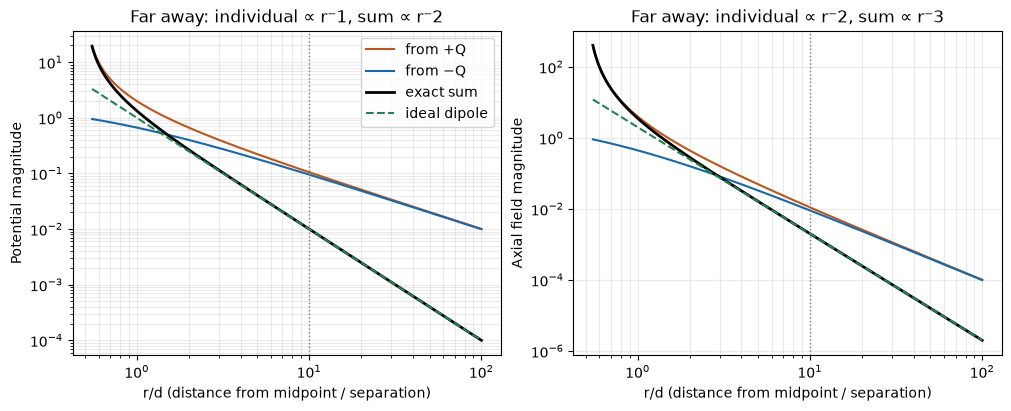

Far-field potential slope: -2.0001 (expected -2)
Far-field field slope: -3.0003 (expected -3)


In [3]:
d, Q = 1.0, 1.0
r = np.geomspace(0.55*d, 100*d, 350)
plus, minus, total = charge_pair(np.zeros_like(r), r, d, Q)
dip = ideal_dipole(np.zeros_like(r), r, p=Q*d)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, component, label, powers in zip(axes, [0, 2], ["Potential magnitude", "Axial field magnitude"], [(1,2),(2,3)]):
    ax.loglog(r/d, np.abs(plus[component]), color="#bd561b", label="from +Q")
    ax.loglog(r/d, np.abs(minus[component]), color="#1769aa", label="from −Q")
    ax.loglog(r/d, np.abs(total[component]), color="black", lw=2, label="exact sum")
    ax.loglog(r/d, np.abs(dip[component]), color="#228452", ls="--", label="ideal dipole")
    ax.axvline(10, color="gray", ls=":", lw=1)
    ax.set(xlabel="r/d (distance from midpoint / separation)", ylabel=label,
           title=f"Far away: individual ∝ r⁻{powers[0]}, sum ∝ r⁻{powers[1]}")
    ax.grid(alpha=.25, which="both")
axes[0].legend()
plt.show()

# Estimate the far-field logarithmic slopes from the exact sum.
for component, name, expected in [(0, "potential", -2), (2, "field", -3)]:
    slope = np.polyfit(np.log(r[-60:]), np.log(np.abs(total[component,-60:])), 1)[0]
    assert abs(slope-expected) < 0.002
    print(f"Far-field {name} slope: {slope:.4f} (expected {expected})")


## Carry the idea forward

The electric pair makes cancellation concrete. A magnetic current loop has no physical monopole charges, but its leading external dipole field has the same geometrical form. A scalar potential is available in the current-free exterior domain described in the text.

Next, work through **two opposing dipoles** in {doc}`exercises`. Cancelling the dipole moment removes another leading contribution. Predict the new powers of distance before calculating them.
